Using device cuda


100%|██████████| 50/50 [00:17<00:00,  2.89it/s]


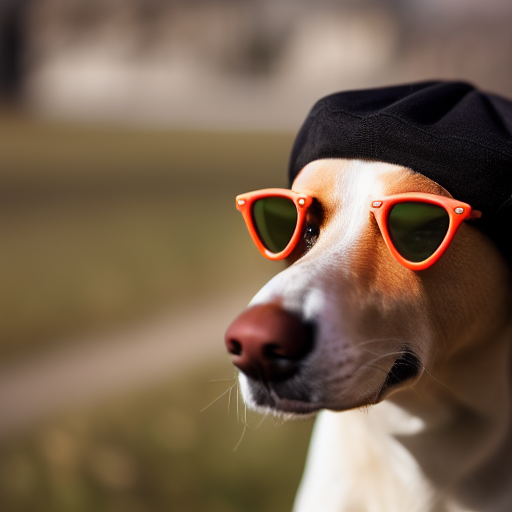

In [1]:
from src import model_loader
from src import pipeline
from PIL import Image
from transformers import CLIPTokenizer
import torch

DEVICE = 'cpu'
IDLE_DEVICE = 'cpu'
ALLOW_CUDA = True
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
  DEVICE = 'cuda'
elif torch.backends.mps.is_built() and ALLOW_MPS:
  DEVICE = 'mps'
print(f'Using device {DEVICE}')

tokenizer = CLIPTokenizer(vocab_file='./data/vocab.json', merges_file='./data/merges.txt')
model_file = './data/v1-5-pruned-emaonly.ckpt'
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE, IDLE_DEVICE)

# Text to Image
prompt = "A dog with sunglasses, wearing comfy hat, looking at camera, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ''
do_cfg = True
cfg_scale = 7

# Image to image
input_image = None
image_path = 'images/dog.jpg'
# input image = Image.open(image_path)
strength = 0.9

sampler = 'ddpm'
num_inference_steps = 50
seed = 42

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device=IDLE_DEVICE,
    tokenizer=tokenizer,
)

# Combine the input image and the output image into a single image.
Image.fromarray(output_image)